# 탐색적 데이터 분석(EDA)



## 탐색적 데이터 분석(EDA)이란?

**탐색적 데이터 분석(Exploratory Data Analysis, EDA)은 데이터의 특성과 패턴을 이해하기 위해 다양한 통계적 기법과 시각화를 통해 데이터를 탐색하는 과정입니다.**

```markdown
데이터가 말하는 '패턴(Pattern)'을 발견하고 그것이 '진실(Fact)'인지 검증하는 단계입니다.
```

**EDA가 데이터 분석에서 중요한 이유**
- **숨겨진 패턴 발견**: 데이터 속에 감춰진 의미 있는 관계와 트렌드 파악
- **문제 조기 발견**: 결측치, 이상치, 데이터 품질 문제 사전 탐지
- **가설 생성 및 검증**: 데이터 기반의 과학적 가설 수립
- **분석 방향 설정**: 후속 분석과 모델링의 전략적 로드맵 구축

**의료 분야에서는** 환자 집단의 특성 파악, 질병 패턴 분석, 치료 효과 검증 등에 활용됩니다.

### 데이터 분석 프로세스


올바른 데이터 분석 프로세스를 따라 진행합니다.  
데이터를 이해해야 어떤 전처리가 필요한지 알 수 있고, 올바른 분석 방향을 설정할 수 있습니다.

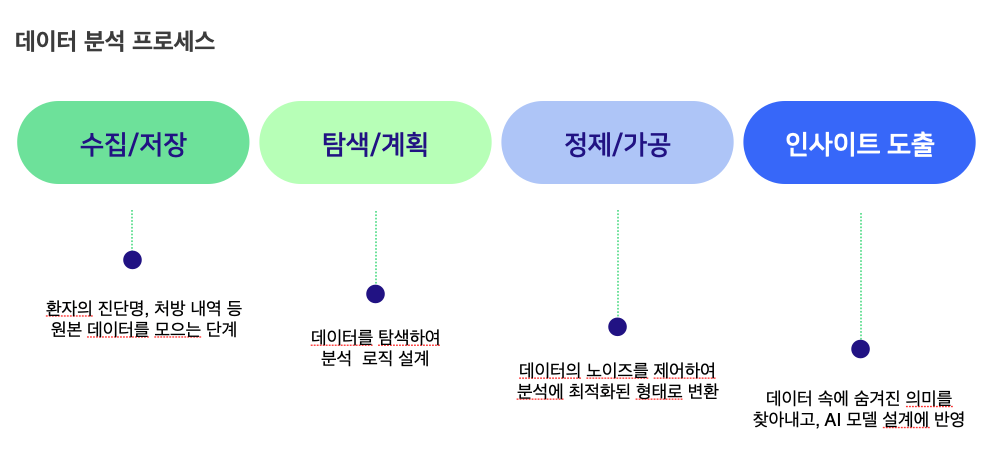



## 필요한 라이브러리 import



In [2]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [4]:
# 데이터 분석 및 처리용 라이브러리
import pandas as pd
import numpy as np

# 시각화 라이브러리
import matplotlib.pyplot as plt

# 통계 분석 라이브러리
from scipy import stats

# 한글 폰트 설정 (그래프에서 한글 깨짐 방지)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False# 마이너스 기호 깨짐 방지

# 경고 메시지 숨기기
import warnings
warnings.filterwarnings('ignore')

print("라이브러리 로딩 완료!")

라이브러리 로딩 완료!


NanumBarunGothicBold.ttf   NanumGothicCoding.ttf  NanumSquareB.ttf
NanumBarunGothic.ttf	   NanumGothic.ttf	  NanumSquareRoundB.ttf
NanumGothicBold.ttf	   NanumMyeongjoBold.ttf  NanumSquareRoundR.ttf
NanumGothicCodingBold.ttf  NanumMyeongjo.ttf	  NanumSquareR.ttf


In [5]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
[f.name for f in fm.fontManager.ttflist if "Malgun" in f.name]

['Malgun Gothic', 'Malgun Gothic', 'Malgun Gothic']

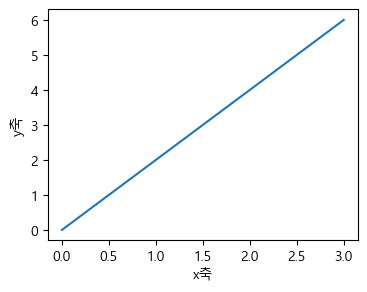

In [6]:
import matplotlib.pyplot as plt
import numpy as np
x=np.arange(4)
y=x*2
plt.figure(figsize=(4, 3))
plt.rc('font', family='Malgun Gothic')
plt.plot(x, y)
plt.xlabel('x축')
plt.ylabel('y축')

plt.show()

## 실제 의료 데이터 로딩

**BRFSS 2015 당뇨병 데이터셋**을 활용합니다.  
미국 질병통제예방센터(CDC)의 Behavioral Risk Factor Surveillance System에서 수집한 실제 건강 지표 데이터입니다.




In [9]:
# 1. 라이브러리 설치 (최초 1회)


In [8]:
# 2. 데이터 다운로드
import kagglehub

# 당뇨병 건강지표 데이터셋 다운로드 (자동으로 최신 버전 받아옴)
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")

print("데이터가 다운로드된 경로:", path)

# 3. 다운로드된 경로에서 파일 불러오기
df = pd.read_csv(f"{path}/diabetes_binary_health_indicators_BRFSS2015.csv")

df.head()


100%|██████████| 6.03M/6.03M [00:00<00:00, 17.4MB/s]

Extracting files...


데이터가 다운로드된 경로: C:\Users\sdh08\.cache\kagglehub\datasets\alexteboul\diabetes-health-indicators-dataset\versions\1


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


**데이터셋 변수(Feature)**

이 데이터셋의 각 변수는 AI 모델에서 핵심적으로 활용되는 건강 지표들입니다.



In [ ]:
# 타겟 변수 (예측 대상)
target_variable = 'Diabetes_binary'  # 당뇨병 진단 여부 (0=없음, 1=있음) - AI 분류 모델의 예측 타겟

```
================================================================================
📊 BRFSS 2015 당뇨병 데이터셋 변수별 상세 (22개 변수)
================================================================================

🩺 생리학적 지표 (AI 모델의 핵심 피처)
BMI              체질량지수 - 비만도 측정, 당뇨병 예측의 가장 중요한 지표
HighBP           고혈압 여부 (0=없음, 1=있음) - 심혈관 위험도 평가 핵심
HighChol         고콜레스테롤 여부 (0=없음, 1=있음) - 대사증후군 진단 중요
CholCheck           콜레스테롤 검사 여부 (0=안함, 1=함) - 건강관리 의식 지표

💊 질병력 (AI 위험도 모델링의 강력한 예측인자)  
Stroke              뇌졸중 병력 (0=없음, 1=있음)
HeartDiseaseorAttack 심장병/심장마비 병력 (0=없음, 1=있음)

🏃‍♂️ 생활습관 지표 (예방의학 AI의 주요 변수)
PhysActivity     신체활동 여부 (0=안함, 1=함)
Fruits           과일 섭취 여부 (0=안함, 1=함)
Veggies          채소 섭취 여부 (0=안함, 1=함)
Smoker           흡연 경험 여부 (0=없음, 1=있음)
HvyAlcoholConsump 과음 여부 (0=안함, 1=함)

🏥 의료접근성 지표 (헬스케어 형평성 AI 연구에 활용) ❌
AnyHealthcare       의료보험 여부 (0=없음, 1=있음)
NoDocbcCost         비용때문에 의료진료 못받은 경험 (0=없음, 1=있음)

😷 건강상태 지표 (AI 건강점수 모델링에 사용)
GenHlth          전반적 건강상태 (1=매우좋음 ~ 5=매우나쁨)
MentHlth         정신건강 불량일수 (최근 30일, 0-30일)  
PhysHlth         신체건강 불량일수 (최근 30일, 0-30일)
DiffWalk         보행 곤란 여부 (0=없음, 1=있음)

👤 인구학적 지표 (AI 모델의 편향 제거와 개인화에 중요)
Sex              성별 (0=여성, 1=남성)
Age              연령대 (1=18-24세, 2=25-29세, ..., 13=80세이상)
Education        교육수준 (1=초등학교미만, 6=대학원이상)
Income           소득수준 (1=1만달러미만, 8=7만5천달러이상)
```

### 기본 데이터 정보 확인

In [ ]:
# 기본 데이터 정보 확인
print("=== 데이터 기본 정보 ===")
print(f"데이터 크기: {df.shape}")
print(f"총 환자 수: {df.shape[0]:,}명")
print(f"총 변수 수: {df.shape[1]}개")


=== 데이터 기본 정보 ===
데이터 크기: (253680, 22)
총 환자 수: 253,680명
총 변수 수: 22개


In [ ]:
print("=== 데이터 타입 정보 ===")
df.info() # 데이터 정보 출력

=== 데이터 타입 정보 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_binary       253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-n

- **info()**: 데이터프레임의 전반적인 구조와 품질 정보를 한 번에 출력하는 함수 (반환값 없음)
- **info 메서드의 주요 정보**
  - **Index**: 인덱스 범위와 타입 (예: RangeIndex: 0 to 253679)
  - **Entries**: 전체 행(레코드) 개수
  - **Data columns**: 전체 컬럼 수와 각 컬럼명 리스트
  - **Column**: 각 컬럼의 순서번호와 이름
  - **Non-Null Count**: 각 컬럼별 결측치가 아닌 실제 데이터 개수
  - **Dtype**: 각 컬럼의 데이터 타입 (int64, float64, object 등)
  - **Memory usage**: 데이터프레임이 메모리에서 차지하는 용량
  - **Dtypes summary**: 데이터 타입별 컬럼 개수 요약

## 📋 EDA 분석 로드맵

**1단계: 데이터 전체 파악**
→ 데이터 전반적 특성 이해  - 기술통계

**2단계: 타겟별 차이 탐색**
→ "당뇨병 환자와 정상인이 다를까?" - 그룹분석

**3단계: 차이의 진위 검증**
→ "관찰된 차이가 진짜일까?" - 통계검정

**4단계: 변수간 관계 파악**
→ "어떤 변수들이 함께 움직일까?" - 상관관계

## 📊 기술통계 분석



### 데이터 개요 파악

**기술통계를 개별적으로 계산하기 전에 전체적인 데이터 특성을 한눈에 파악할 수 있습니다**

데이터의 전반적인 분포와 특성을 빠르게 파악하여 이상한 값이나 예상과 다른 패턴을 조기에 발견할 수 있습니다.   
의료 데이터에서는 정상 범위를 벗어나는 값들을 미리 확인할 수 있어 데이터 품질 점검에 필수적입니다.

**📚 핵심 개념 이해**
- **describe()**: 수치형 변수들의 주요 통계량을 한 번에 계산해주는 함수
- **describe 메서드의 8개 통계량**
  - **count (개수)**: 결측치를 제외한 실제 데이터 개수
  - **mean (평균)**: 모든 값의 합계를 개수로 나눈 값, 중심경향성의 대표값
  - **std (표준편차)**: 데이터가 평균에서 얼마나 퍼져있는지 나타내는 지표
  - **min (최솟값)**: 가장 작은 값, 데이터 범위의 하한선
  - **25% (1사분위수)**: 하위 25% 지점의 값, Q1
  - **50% (중앙값)**: 중간 지점의 값, Q2, 중앙값과 같음
  - **75% (3사분위수)**: 상위 25% 지점의 값, Q3
  - **max (최댓값)**: 가장 큰 값, 데이터 범위의 상한선
- **빠른 데이터 체크**: 이상치, 결측치, 분포 특성을 즉시 파악 가능


💡 **우리 데이터셋 예시**:
- **BMI**: 정상 범위(18-40) 내에 있는지 확인
- **Age**: 연령대 분포가 고르게 되어있는지 확인
- **MentHlth, PhysHlth**: 0-30일 범위 내에 있는지 확인


In [ ]:
# 수치형 변수 전체 기술통계 요약
print("=== 전체 데이터 기술통계 요약 ===")
numeric_summary = df.describe()
print(numeric_summary.round(2))  # 소수점 둘째자리까지 표시

print(f"\n💡 주요 확인 포인트:")
print(f"📊 데이터 개수: 모든 변수가 {len(df):,}개로 동일한지 확인")
print(f"📊 BMI 범위: {df['BMI'].min():.1f} ~ {df['BMI'].max():.1f} (의학적으로 타당한가?)")
print(f"📊 연령 분포: 1~13 범위의 연령대로 고르게 분포")
print(f"📊 건강일수: MentHlth, PhysHlth가 0~30일 범위 내에 있는지 확인")

=== 전체 데이터 기술통계 요약 ===
       Diabetes_binary     HighBP   HighChol  CholCheck        BMI     Smoker  \
count        253680.00  253680.00  253680.00  253680.00  253680.00  253680.00   
mean              0.14       0.43       0.42       0.96      28.38       0.44   
std               0.35       0.49       0.49       0.19       6.61       0.50   
min               0.00       0.00       0.00       0.00      12.00       0.00   
25%               0.00       0.00       0.00       1.00      24.00       0.00   
50%               0.00       0.00       0.00       1.00      27.00       0.00   
75%               0.00       1.00       1.00       1.00      31.00       1.00   
max               1.00       1.00       1.00       1.00      98.00       1.00   

          Stroke  HeartDiseaseorAttack  PhysActivity     Fruits  ...  \
count  253680.00             253680.00     253680.00  253680.00  ...   
mean        0.04                  0.09          0.76       0.63  ...   
std         0.20               

### 정규분포 이해하기

**정규분포는 데이터 분석에서 가장 자주 만나는 분포 형태입니다.**

많은 통계 기법과 머신러닝 알고리즘이 데이터가 정규분포를 따른다고 가정합니다.   
의료 데이터에서 BMI, 혈압 같은 생체 지표들이 종종 정규분포와 비슷한 형태를 보입니다.

<img src="https://cdn.newshyu.com/news/photo/202005/825445_27725_2132.jpg" width="600">

**📚 핵심 개념 이해**
- **정규분포**: 평균을 중심으로 좌우 대칭인 종 모양 분포
- **평균 = 중앙값**: 정규분포에서는 평균과 중앙값이 거의 같음
- **표준화**: (값-평균)/표준편차로 변환하여 비교 가능


💡 **활용 예시**
- **Age**: 연령대별로 고르게 분포되어 있을 수 있음
- **MentHlth**: 0일이 많고 30일이 적은 오른쪽으로 꼬리가 긴(Right-Skewed) 분포일 가능성


### 중심경향성 분석 (Central Tendency)

**중심경향성은 데이터가 어느 값 주변에 모여있는지 나타내는 대표값들입니다.**

결측치 대체(imputation)에서 평균이나 중앙값으로 빈 데이터를 채울 때 사용합니다.  
의료 데이터에서는 환자의 누락된 혈압, BMI 등을 채워 모든 환자 데이터를 모델 학습에 활용할 수 있게 합니다.

**대표값(3m)**
- **평균 (Mean)**: 모든 값을 더해 N으로 나눈 것. (이상치에 취약함)
- **중앙값 (Median)**: 데이터를 줄 세웠을 때 정중앙에 위치한 값. (이상치에 강함)  
- **최빈값 (Mode)**: 가장 자주 나타나는 값. 범주형 데이터에서 주로 사용



#### 평균 (Mean)

데이터의 **무게 중심**입니다.  
모든 데이터를 더해서 개수로 나눈 값으로, 데이터가 한쪽으로 치우치지 않고 고르게 분포(정규분포)할 때 가장 좋은 대표값입니다.

**적용 상황**

- 데이터가 정규분포에 근사하거나, 좌우 대칭인 경우

- 키, 체중, 체온 등 극단적인 값이 드문 생체 지표 분석

<img src="https://blog.bizspring.co.kr/wp-content/uploads/2018/01/%EB%8B%A4%EC%9A%B4%EB%A1%9C%EB%93%9C.png" width="500">

**⚠️ 주의사항**  

평균은 **이상치(Outlier)에** 매우 민감합니다. 극단적인 값이 소수만 포함되어도 전체 대표값이 왜곡될 위험이 있습니다.

💡 활용 예시: 신생아 체중 산부인과에서 신생아 10명의 체중을 측정할 때, 대다수가 2.8kg~3.8kg 범위에 분포한다면 **평균값(3.3kg)**은 전체 집단의 발육 상태를 효과적으로 설명하는 지표가 됩니다.




#### 중앙값 (Median)

데이터를 크기순으로 나열했을 때 **정중앙(50% 백분위수)에** 위치한 값입니다.  
평균의 왜곡을 보완하는 강건한(Robust) 대표값입니다.

**적용 상황**

* 데이터의 분포가 비대칭이거나(Skewed), 꼬리가 긴 형태일 때
* 소득, 의료비, 재원 기간 등 극단적인 이상치가 포함될 가능성이 높은 데이터

<img src="https://img1.daumcdn.net/thumb/R800x0/?scode=mtistory2&fname=https%3A%2F%2Fblog.kakaocdn.net%2Fdna%2FcGrK7B%2FbtqS1Wq0WCb%2FAAAAAAAAAAAAAAAAAAAAAHWxESFHLuGvySRRFGVcC77NlJXDck9JWN2HYaK-m07D%2Fimg.png%3Fcredential%3DyqXZFxpELC7KVnFOS48ylbz2pIh7yKj8%26expires%3D1767193199%26allow_ip%3D%26allow_referer%3D%26signature%3Dwuc5N04XMyhGcTWxaz2BgY8XDXc%253D" width="800">

**💡 활용예시**  

"본 병원의 평균 재원 기간은 61.6일입니다"라는 통계는 환자 경험과 괴리가 있을 수 있습니다.
* **실제:** 4명은 **2일** 만에 퇴원했으나, 1명이 **300일** 장기 입원 중인 경우
* **평균:** 극단값(300일)의 영향으로 **61.6일**이라는 왜곡된 수치 산출

일반적인 환자의 입원 기간을 파악할 때는 이상치의 영향을 배제한 **중앙값(2일)이** 임상적 현실을 더 정확하게 반영합니다.



#### 최빈값 (Mode)

전체 데이터 중 **빈도수(Frequency)가 가장 높은 값**을 의미합니다. 수치적 크기보다는 빈번한 발생 여부가 중요한 경우에 사용됩니다.

**적용 상황**

* **범주형 데이터** (성별, 혈액형, 진단명, 질병 분류 코드)의 대표값 산출
* 산술 평균이 물리적으로 불가능하거나 무의미한 경우 (예: 옷 사이즈, 약물 개수)

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/5/5e/Bar_chart_mode_01.svg/1200px-Bar_chart_mode_01.svg.png" width="600">

**💡 활용예시**

"특정 약물의 1회 처방량을 분석한 결과, 평균이 **'1.4알'로** 산출되었다"고 가정해 봅시다.

* **평균:** '1.4알'이라는 약물 단위는 존재하지 않습니다. 이 수치만으로는 1알 단위 포장을 준비해야 할지, 2알 단위 포장을 준비해야 할지 알 수 없어 재고 관리가 불가능합니다.
* **최빈값:** 확인 결과 **'1알'이** 가장 많았습니다(최빈값). 이는 소수점 단위의 특수 포장보다는, 표준 1알 단위의 약품 재고를 최우선으로 확보해야 함을 시사합니다.

약물의 개수나 포장 단위 같은 이산형 데이터에서는 물리적으로 불가능한 평균값(소수점)보다, 실제 처방과 물류에 바로 적용할 수 있는 최빈값이 의사결정의 기준이 됩니다.




**의료데이터 활용**
- **MentHlth(정신건강 불량일수)**: 대부분 0일인데 일부가 30일이면 → 중앙값 사용
- **Age(연령대)**: 1-13 범위의 고른 분포 → 평균 사용 가능
- **GenHlth(건강상태)**: 1-5 점수, 3점이 가장 많다면 → 최빈값(3점) 의미있음



In [10]:
# 연속형 변수들의 중심경향성 분석
continuous_vars = [
    'BMI',         # 체질량지수
    'MentHlth',    # 정신건강 불량일수
    'PhysHlth',    # 신체건강 불량일수
    'Age'          # 연령대
]

for col in continuous_vars:
    if col in df.columns:
        print(f"\n📊 {col}:")
        print(f"  평균 (Mean): {df[col].mean():.2f}")          # 모든 값의 합 / 개수
        print(f"  중앙값 (Median): {df[col].median():.2f}")    # 순서대로 나열했을 때 가운데 값

        # 최빈값 계산 (pandas mode 사용)
        mode_values = df[col].mode()                           # 가장 자주 나타나는 값
        if len(mode_values) > 0:
            print(f"  최빈값 (Mode): {mode_values[0]:.2f}")
        else:
            print(f"  최빈값 (Mode): 없음")



📊 BMI:
  평균 (Mean): 28.38
  중앙값 (Median): 27.00
  최빈값 (Mode): 27.00

📊 MentHlth:
  평균 (Mean): 3.18
  중앙값 (Median): 0.00
  최빈값 (Mode): 0.00

📊 PhysHlth:
  평균 (Mean): 4.24
  중앙값 (Median): 0.00
  최빈값 (Mode): 0.00

📊 Age:
  평균 (Mean): 8.03
  중앙값 (Median): 8.00
  최빈값 (Mode): 9.00


### 분산성 분석 (Variability)

**분산성은 데이터가 중심값 주변에서 얼마나 퍼져있는지를 나타냅니다.**

데이터 정규화(Normalization)에서 표준편차를 이용해 서로 다른 단위의 변수들을 동일한 스케일로 맞출 때 사용합니다.   
의료 데이터에서는 BMI(kg/m²)와 나이(세)처럼 단위가 다른 변수들을 표준화해야 모델이 공정하게 학습할 수 있습니다.

**📚 핵심 개념 이해**
- **분산 (Variance)**: 표준편차를 제곱한 값. 계산용이라 실제 해석은 표준편차 사용
- **범위 (Range)**: 최댓값 - 최솟값으로 데이터가 퍼져있는 전체 폭. 데이터 스케일 파악과 정규화에 활용하지만 극값 하나로 크게 왜곡됨



#### 표준편차 (Standard Deviation)

**데이터가 평균에서 얼마나 떨어져 있는지 보여주는 핵심 지표입니다.**

<img src="https://velog.velcdn.com/images%2Fyuns_u%2Fpost%2F82694751-8ef2-484e-8cc2-2b9c0a0dccb3%2Fimage.png" width="600">

**⚠️ 주의사항**  
평균 혈당이 똑같이 100이라도, 상태는 천지 차이일 수 있습니다. 이때 **표준편차(Std)**를 봐야 합니다.
- 환자 A (표준편차 5): 혈당이 95~105 사이에서 놉니다. → "관리 잘 됨 (안정)"
- 환자 B (표준편차 60): 혈당이 40(저혈당 쇼크) 갔다가 160(고혈당) 갑니다. → "매우 위험 (불안정)"
- 결론: AI 모델 입장에서 표준편차가 큰 환자는 **"예측이 어렵고 위험한 케이스"**로 분류됩니다.

💡 **활용 예시**: BMI 표준편차가 클수록 다양한 체형의 환자 포함



In [ ]:
# 1. 표준편차 분석 - BMI (연속형 데이터의 대표)
bmi_mean = df['BMI'].mean()
bmi_std = df['BMI'].std()
print(f"BMI 평균: {bmi_mean:.2f}")
print(f"BMI 표준편차: {bmi_std:.2f}")                     # 데이터가 평균에서 얼마나 떨어져 있는지

print(f"💡 해석:", end=" ")

bmi_cv = (bmi_std / bmi_mean) * 100                     # 평균 칠 때 표준편차가 몇 %나 되는지

if bmi_cv < 10:
    print("데이터가 평균 근처에 매우 밀집해 있습니다. (매우 안정적)")
elif bmi_cv < 30:
    print("데이터가 적당히 퍼져 있습니다. (일반적인 수준)")
else: # 30% 이상
    print("데이터가 평균에서 아주 멀리 흩어져 있습니다. (매우 불안정/이질적 집단)")

BMI 평균: 28.38
BMI 표준편차: 6.61
💡 해석: 데이터가 적당히 퍼져 있습니다. (일반적인 수준)


In [ ]:

# 2. 분산 vs 표준편차 비교 - BMI
bmi_variance = df['BMI'].var()
print(f"BMI 분산: {bmi_variance:.2f}")                     # 표준편차의 제곱 (계산용)
print(f"BMI 표준편차: {bmi_std:.2f}")
print(f"💡 해석: 분산({bmi_variance:.1f})보다 표준편차({bmi_std:.1f})가 실제 해석에 유용")



BMI 분산: 43.67
BMI 표준편차: 6.61
💡 해석: 분산(43.7)보다 표준편차(6.6)가 실제 해석에 유용


In [ ]:
# 3. 범위 분석 - BMI (극값에 영향받기 쉬운 데이터)
ment_min = df['BMI'].min()
ment_max = df['BMI'].max()
ment_range = ment_max - ment_min
print(f"범위 (Range): {ment_min:.2f} ~ {ment_max:.2f} (결과: {ment_range:.0f})")  # 최솟값부터 최댓값까지


범위 (Range): 12.00 ~ 98.00 (결과: 86)


#### 사분위간범위 (IQR)

**상위 25%와 하위 25%를 제외한 중간 50% 구간의 폭으로, 극값에 영향받지 않는 안정적인 지표입니다.**


<img src="https://blog.kakaocdn.net/dna/Nfi3Q/btsJhjA4XqO/AAAAAAAAAAAAAAAAAAAAAMJjbPilSd90Vx7xvGQ31b1Rse7MXCwhStyv1naClmmY/img.png?credential=yqXZFxpELC7KVnFOS48ylbz2pIh7yKj8&expires=1769871599&allow_ip=&allow_referer=&signature=5tioAGNsFAktR3FrE3qJaRZi184%3D" width="600">

💡 **활용 예시**: MentHlth에서 IQR을 사용하면 극단적인 우울증 환자의 영향을 배제하고 일반적인 환자군의 분포를 파악할 수 있습니다.

In [ ]:
# 4. IQR 분석 - BMI (극값에 강한 지표)
print(f"사분위간범위(IQR): BMI")
# IQR = Q3 지점의 값 - Q1 지점의 값 (중간 50%가 분포된 범위의 폭)
q1 = df['BMI'].quantile(0.25)  # 25% 지점의 실제 값
q3 = df['BMI'].quantile(0.75)  # 75% 지점의 실제 값
iqr = q3 - q1             # 두 지점 사이의 거리 = 중간 50% 분포 폭

print(f"Q1 (25% 지점): {q1:.1f}")
print(f"Q3 (75% 지점): {q3:.1f}")
print(f"IQR: {iqr:.1f}")
print(f"💡 해석: 중간 50%의 환자는 {iqr:.1f} 범위 내에서 분포")
print(f"✅ 장점: 극값에 영향받지 않는 안정적인 지표")



사분위간범위(IQR): BMI
Q1 (25% 지점): 24.0
Q3 (75% 지점): 31.0
IQR: 7.0
💡 해석: 중간 50%의 환자는 7.0 범위 내에서 분포
✅ 장점: 극값에 영향받지 않는 안정적인 지표


### 🤔 실습 문제: 기술통계 분석

당뇨병 데이터(df)에서 다음 통계량을 직접 계산해보세요.

**문제**: PhysHlth(신체건강 불량일수) 변수의 기본 통계량을 구하세요.
- 평균값을 계산하고 소수점 둘째자리까지 출력
- 중앙값 계산
- 표준편차를 계산하고 소수점 둘째자리까지 출력

**힌트**
- 평균: `.mean()` 사용
- 중앙값: `.median()` 사용  
- 표준편차: `.std()` 사용
- 반올림: `round(값, 2)` 사용



In [29]:
# 여기에 작성하세요

# 교육수준별 분포 분석
print("=== 교육수준(Education) 분포 분석 ===")

print(f"{df['PhysHlth'].mean():.1f}")
print(f"{df['PhysHlth'].median():.1f}")
print(f"{df['PhysHlth'].std():.2f}")

=== 교육수준(Education) 분포 분석 ===
4.2
0.0
8.72


In [ ]:
# @title 정답

# PhysHlth 변수의 기본 통계량 계산
print("=== PhysHlth(신체건강 불량일수) 기본 통계량 ===")

# 평균값
physhlth_mean = df['PhysHlth'].mean()
print(f"평균: {physhlth_mean:.2f}일")

# 중앙값
physhlth_median = df['PhysHlth'].median()
print(f"중앙값: {physhlth_median:.1f}일")

# 표준편차
physhlth_std = df['PhysHlth'].std()
print(f"표준편차: {physhlth_std:.2f}일")

print(f"\n해석:")
print(f"평균 {physhlth_mean:.1f}일은 대부분의 사람들이 신체적으로 건강하다는 의미")
print(f"표준편차 {physhlth_std:.1f}일로 개인차가 존재함")

=== PhysHlth(신체건강 불량일수) 기본 통계량 ===
평균: 4.24일
중앙값: 0.0일
표준편차: 8.72일

해석:
평균 4.2일은 대부분의 사람들이 신체적으로 건강하다는 의미
표준편차 8.7일로 개인차가 존재함


### 빈도 및 교차분석



#### 빈도분석

**빈도분석은 범주형 데이터에서 각 카테고리가 얼마나 자주 나타나는지 확인하는 기법입니다.**

클래스 불균형(Class Imbalance) 문제를 파악해서 모델 학습 전략을 결정할 때 사용합니다.   
의료 데이터에서는 희귀질환 환자가 전체의 5%만 차지한다면 가중치 조정 등의 기법을 적용해야 모델이 소수 클래스도 잘 예측할 수 있습니다.

**📚 핵심 개념 이해**
- **빈도 (Frequency)**: 각 범주가 몇 번 나타나는지 세는 것
- **상대빈도 (Relative Frequency)**: 전체에서 차지하는 비율 (%)

**⚠️ 주의사항**

**당뇨병 환자 비율**이 너무 낮으면(5% 미만) AI 모델이 "모두 정상"이라고 예측해도 95% 정확도를 얻습니다. (고성능 착시현상)  
이런 **불균형 데이터**에서는 조정이 필요합니다.

💡 **활용 예시**
- **Diabetes_binary**: 0과 1의 비율이 7:3이면 → 균형잡힌 데이터
- **Sex**: 남녀 비율이 5:5면 성별 편향 없음
- **GenHlth**: 1-5점 중 3점이 가장 많다면 → 보통 건강상태가 일반적



In [ ]:
# 당뇨병 분포 (타겟 변수)
print("당뇨병 환자 분포:")
diabetes_counts = df['Diabetes_binary'].value_counts()        # 각 값의 개수 계산

# normalize=True: 전체 합이 1이 되도록 비율로 변환
# * 100: 0.25 → 25%로 백분율 변환

diabetes_pct = df['Diabetes_binary'].value_counts(normalize=True) * 100  # 비율을 백분율로 변환 (상대빈도)
for val, count, pct in zip(diabetes_counts.index, diabetes_counts.values, diabetes_pct.values):
    status = "당뇨병" if val == 1 else "정상"
    print(f"{status}: {count:,}명 ({pct:.1f}%)")


당뇨병 환자 분포:
정상: 218,334명 (86.1%)
당뇨병: 35,346명 (13.9%)


In [ ]:
# AI 모델링 활용
diabetes_positive_rate = diabetes_pct[1] if 1 in diabetes_pct.index else 0
print(f"AI 모델링 관점: 당뇨병 환자가 {diabetes_positive_rate:.1f}%")
if diabetes_positive_rate < 20:
    print("⚠️ 소수 클래스이므로 가중치 조정 등의 기법 필요")



AI 모델링 관점: 당뇨병 환자가 13.9%
⚠️ 소수 클래스이므로 가중치 조정 등의 기법 필요


In [ ]:
# 성별 분포
print("성별 분포:")
sex_counts = df['Sex'].value_counts()
sex_pct = df['Sex'].value_counts(normalize=True) * 100
for val, count, pct in zip(sex_counts.index, sex_counts.values, sex_pct.values):
    gender = "남성" if val == 1 else "여성"
    print(f"{gender}: {count:,}명 ({pct:.1f}%)")


성별 분포:
여성: 141,974명 (56.0%)
남성: 111,706명 (44.0%)


In [ ]:
# 건강 상태 분포
print("전반적 건강상태 분포:")
health_labels = {1: "매우 좋음", 2: "좋음", 3: "보통", 4: "나쁨", 5: "매우 나쁨"}

health_counts = df['GenHlth'].value_counts().sort_index()     # 인덱스 순서대로 정렬
health_pct = df['GenHlth'].value_counts(normalize=True).sort_index() * 100

for key, count, pct in zip(health_counts.index, health_counts.values, health_pct.values):
    print(f"({int(key)})  {health_labels[key]}: {count:,}명 ({pct:.1f}%)")


전반적 건강상태 분포:
(1)  매우 좋음: 45,299명 (17.9%)
(2)  좋음: 89,084명 (35.1%)
(3)  보통: 75,646명 (29.8%)
(4)  나쁨: 31,570명 (12.4%)
(5)  매우 나쁨: 12,081명 (4.8%)


### 🤔 실습 문제: 빈도 분석

당뇨병 데이터(df)에서 범주형 변수의 분포를 분석해보세요.

**문제**: 교육수준(Education) 변수의 분포를 분석하세요.
- 각 교육수준별 환자 수 계산 (절대빈도)
- 각 교육수준별 비율 계산 (상대빈도, 백분율)
- 가장 많은 교육수준과 가장 적은 교육수준 찾기

**힌트**
- 절대빈도: `.value_counts()` 사용
- 상대빈도: `.value_counts(normalize=True) * 100` 사용
- 최대값: `.max()`, 최소값: `.min()` 사용
- 인덱스 찾기: `.idxmax()`, `.idxmin()` 사용



In [ ]:
# 여기에 작성하세요

# 교육수준별 분포 분석
print("=== 교육수준(Education) 분포 분석 ===")


In [ ]:
# @title 정답

# 교육수준별 분포 분석
print("=== 교육수준(Education) 분포 분석 ===")

# 1. 절대빈도 (각 교육수준별 환자 수)
education_counts = df['Education'].value_counts().sort_index()      # 각 값을 세어 인덱스(교육수준 번호) 순서대로 정렬
print("교육수준별 환자 수 (절대빈도):")
for edu_level, count in education_counts.items():
    print(f"교육수준 {edu_level}: {count:,}명")

# 2. 상대빈도 (백분율)
education_percent = df['Education'].value_counts(normalize=True).sort_index() * 100     # 비율을 백분율로 변환
print(f"\n교육수준별 비율 (상대빈도):")
for edu_level, percent in education_percent.items():
    print(f"교육수준 {edu_level}: {percent:.1f}%")

# 3. 최대/최소 교육수준 찾기
# idxmax(): 최댓값을 가진 인덱스(교육수준 번호) 반환
# idxmin(): 최솟값을 가진 인덱스 반환

most_common_edu = education_counts.idxmax()      # 가장 많은 교육수준 번호
least_common_edu = education_counts.idxmin()     # 가장 적은 교육수준 번호
max_count = education_counts.max()
min_count = education_counts.min()

print(f"\n분석 결과:")
print(f"가장 많은 교육수준: {most_common_edu}단계 ({max_count:,}명, {education_percent[most_common_edu]:.1f}%)")
print(f"가장 적은 교육수준: {least_common_edu}단계 ({min_count:,}명, {education_percent[least_common_edu]:.1f}%)")

=== 교육수준(Education) 분포 분석 ===
교육수준별 환자 수 (절대빈도):
교육수준 1.0: 174명
교육수준 2.0: 4,043명
교육수준 3.0: 9,478명
교육수준 4.0: 62,750명
교육수준 5.0: 69,910명
교육수준 6.0: 107,325명

교육수준별 비율 (상대빈도):
교육수준 1.0: 0.1%
교육수준 2.0: 1.6%
교육수준 3.0: 3.7%
교육수준 4.0: 24.7%
교육수준 5.0: 27.6%
교육수준 6.0: 42.3%

분석 결과:
가장 많은 교육수준: 6.0단계 (107,325명, 42.3%)
가장 적은 교육수준: 1.0단계 (174명, 0.1%)


#### 교차분석 (Crosstab)

**교차분석은 두 범주형 변수 간의 관계를 표 형태로 분석하는 기법입니다.**

변수의 빈도(frequency)를 교차로 묶어 표(교차표, 분할표)로 만들고, 이를 통해 특정 범주 조합의 빈도가 우연히 발생한 것인지 통계적으로 유의미한지 확인합니다.




In [ ]:
# 당뇨병과 고혈압의 관계 분석

# pd.crosstab(): 두 범주형 변수 간의 빈도표 생성 (2x2 테이블)
# margins=True: 행/열 합계(총계) 자동 추가

crosstab_result = pd.crosstab(df['Diabetes_binary'], df['HighBP'], margins=True)

crosstab_result


HighBP,0.0,1.0,All
Diabetes_binary,,,
0.0,136109,82225,218334
1.0,8742,26604,35346
All,144851,108829,253680


In [ ]:
print("=== 당뇨병 vs 고혈압 교차분석 ===")

crosstab_result.index = ['정상', '당뇨병', '총계']       # 0: 정상,  1: 당뇨병
crosstab_result.columns = ['정상혈압', '고혈압', '총계']  # 0: 정상혈압,  2: 고혈압
print(crosstab_result)

# 비율로 표현 (각 행의 합이 100%가 되도록 정규화)
print("\n=== 비율로 표현 (%) ===")

# normalize='index': 행별로 정규화 (정상군 내에서의 비율, 당뇨병군 내에서의 비율)
# * 100: 소수점을 백분율로 변환 (0.75 → 75%)

crosstab_pct = pd.crosstab(df['Diabetes_binary'], df['HighBP'], normalize='index') * 100
crosstab_pct.index = ['정상', '당뇨병']
crosstab_pct.columns = ['정상혈압', '고혈압']
print(crosstab_pct.round(1))

print(f"\n💡 AI 인사이트: 당뇨병 환자 중 {crosstab_pct.loc['당뇨병', '고혈압']:.1f}%가 고혈압")
print("  → 두 질환의 강한 연관성으로 복합 위험도 모델링 가능")

=== 당뇨병 vs 고혈압 교차분석 ===
       정상혈압     고혈압      총계
정상   136109   82225  218334
당뇨병    8742   26604   35346
총계   144851  108829  253680

=== 비율로 표현 (%) ===
     정상혈압   고혈압
정상   62.3  37.7
당뇨병  24.7  75.3

💡 AI 인사이트: 당뇨병 환자 중 75.3%가 고혈압
  → 두 질환의 강한 연관성으로 복합 위험도 모델링 가능


### 🤔 실습 문제: 교차분석

당뇨병 데이터(df)에서 두 범주형 변수 간의 관계를 분석해보세요.

**문제**: 흡연경험(Smoker)과 심장병(HeartDiseaseorAttack)의 관계를 교차분석하세요.
- 두 변수의 교차표(crosstab) 생성
- 행별 비율로 변환 (각 흡연 그룹 내에서의 심장병 비율)
- 흡연자와 비흡연자 중 누가 심장병 비율이 높은지 분석

**힌트**
- 교차표: `pd.crosstab(행변수, 열변수)` 사용
- 행별 비율: `pd.crosstab(행변수, 열변수, normalize='index') * 100`
- 변수값: 0=없음, 1=있음



In [ ]:
# 여기에 작성하세요

# 흡연과 심장병의 교차분석
print("=== 흡연경험과 심장병 교차분석 ===")


In [ ]:
# @title 정답

# 흡연과 심장병의 교차분석
print("=== 흡연경험과 심장병 교차분석 ===")

# 1. 교차표 생성 (절대빈도)
crosstab_smoking_heart = pd.crosstab(df['Smoker'], df['HeartDiseaseorAttack'], margins=True)

# 행: 흡연경험 (0=없음, 1=있음)
# 열: 심장병 (0=없음, 1=있음)
crosstab_smoking_heart.index = ['비흡연자(0)', '흡연자(1)', '전체']
crosstab_smoking_heart.columns = ['심장병없음(0)', '심장병있음(1)', '전체']
print("교차표 (절대빈도):")
print(crosstab_smoking_heart)

# 2. 행별 비율 계산 (각 흡연 그룹 내에서의 심장병 비율)
crosstab_percent = pd.crosstab(df['Smoker'], df['HeartDiseaseorAttack'], normalize='index') * 100
crosstab_percent.index = ['비흡연자(0)', '흡연자(1)']
crosstab_percent.columns = ['심장병없음(0)', '심장병있음(1)']
print(f"\n행별 비율 (%):")
print(crosstab_percent.round(1))

# 3. 비흡연자 vs 흡연자 심장병 비율 비교
nonsmoker_heart_rate = crosstab_percent.loc['비흡연자(0)', '심장병있음(1)']  # 비흡연자 중 심장병 비율
smoker_heart_rate = crosstab_percent.loc['흡연자(1)', '심장병있음(1)']     # 흡연자 중 심장병 비율

print(f"\n분석 결과:")
print(f"비흡연자 중 심장병 비율: {nonsmoker_heart_rate:.1f}%")
print(f"흡연자 중 심장병 비율: {smoker_heart_rate:.1f}%")

# 차이 계산 및 해석
difference = smoker_heart_rate - nonsmoker_heart_rate
print(f"차이: {difference:.1f}%포인트")

if difference > 0:
    print(f"→ 흡연자가 비흡연자보다 심장병 발생률이 {difference:.1f}%포인트 높음")
else:
    print(f"→ 비흡연자가 흡연자보다 심장병 발생률이 {abs(difference):.1f}%포인트 높음")

=== 흡연경험과 심장병 교차분석 ===
교차표 (절대빈도):
         심장병없음(0)  심장병있음(1)      전체
비흡연자(0)    132165      9092  141257
흡연자(1)      97622     14801  112423
전체         229787     23893  253680

행별 비율 (%):
         심장병없음(0)  심장병있음(1)
비흡연자(0)      93.6       6.4
흡연자(1)       86.8      13.2

분석 결과:
비흡연자 중 심장병 비율: 6.4%
흡연자 중 심장병 비율: 13.2%
차이: 6.7%포인트
→ 흡연자가 비흡연자보다 심장병 발생률이 6.7%포인트 높음


## 👥 그룹별 분석


**그룹별 분석은 타겟 변수의 각 범주에서 다른 변수들이 어떻게 분포되는지 비교하는 핵심 EDA 기법입니다.**

피처 선택(Feature Selection)에서 타겟 변수와 가장 관련성이 높은 변수들을 사전에 파악할 때 사용합니다.    
의료 데이터에서는 당뇨병 환자와 정상인 간에 BMI, 혈압 차이가 클수록 해당 변수가 예측 모델에서 중요한 역할을 할 가능성이 높습니다.



**```groupby()``` 동작 원리**  

<img src="https://www.w3resource.com/w3r_images/pandas-groupby-split-apply-combine.svg" width="600">

1. 분리(Split) 단계: groupby()에서 정의한 컬럼 조건에 따라 독립된 그룹으로 나누어 줍니다.

2. 적용(Apply) 단계: 나뉘어진 독립된 그룹별 함수를 적용하는 단계 입니다. 합계(sum) 혹은 평균(mean)함수를 적용하여 각 그룹별 연산을 적용합니다..

3. 결합(Combine) 단계: 최종 단계이며, 각각의 함수가 적용된 결과를 종합하여 다시 하나의 테이블로 합칩니다.

**📚 핵심 개념 이해**
- **그룹별 분석**: 타겟 변수(당뇨병)의 각 범주별로 다른 변수들의 분포를 비교
- **집계함수**: groupby + mean(), std(), count() 등으로 그룹별 통계 계산
- **효과크기 (Effect Size)**: 차이가 얼마나 실질적으로 의미 있는지 측정


💡 **예시**
- **당뇨병별 BMI**: 당뇨병군 평균 30, 정상군 평균 27 → 3의 차이가 의미있는가?
- **성별별 흡연율**: 남성 40%, 여성 20% → 성별이 흡연에 영향
- **연령대별 당뇨병율**: 고령층에서 높다면 → 연령은 강력한 예측인자



In [ ]:
# 분리 단계
diabetes_groups = df.groupby('Diabetes_binary')

# diabetes_groups.groups    # 분리 확인

In [ ]:
# 1단계: 당뇨병 여부별로 데이터를 나누기
diabetes_groups_bmi = df.groupby('Diabetes_binary')['BMI']  # BMI 컬럼만
print(f"단일컬럼 선택: {diabetes_groups_bmi.ngroups}개 그룹")

for name, data in diabetes_groups_bmi:
  print("name", name)
  print("data", data)
  print("=" * 60 )



단일컬럼 선택: 2개 그룹
name 0.0
data 0         40.0
1         25.0
2         28.0
3         27.0
4         24.0
          ... 
253673    42.0
253674    27.0
253675    45.0
253677    28.0
253678    23.0
Name: BMI, Length: 218334, dtype: float64
name 1.0
data 8         30.0
10        25.0
13        28.0
17        23.0
23        27.0
          ... 
253659    37.0
253668    29.0
253670    25.0
253676    18.0
253679    25.0
Name: BMI, Length: 35346, dtype: float64


In [ ]:
# 각 그룹의 크기 확인
for group_name, group_data in diabetes_groups_bmi:
    group_label = "정상" if group_name == 0 else "당뇨병"
    print(f"{group_label}군: {len(group_data)}명")

# 2-3단계: 적용 및 결합 (mean())
# 단일 컬럼: BMI 평균만
group_means_single = df.groupby('Diabetes_binary')['BMI'].mean()   # mean함수 적용 및 결합
print(f"정상군 BMI 평균: {group_means_single[0]:.2f}")
print(f"당뇨병군 BMI 평균: {group_means_single[1]:.2f}")


정상군: 218334명
당뇨병군: 35346명
정상군 BMI 평균: 27.81
당뇨병군 BMI 평균: 31.94


In [ ]:
# 여러 컬럼도 동시에 선택 가능!
diabetes_groups_multi = df.groupby('Diabetes_binary')[['BMI', 'MentHlth', 'PhysHlth']]  # 여러 컬럼
print(f"여러 컬럼 선택: {diabetes_groups_multi.ngroups}개 그룹 (BMI, 정신건강, 신체건강)")

for name,  data in diabetes_groups_multi:
  print("name", name)
  print("data", data)
  print("=" * 60 )



여러 컬럼 선택: 2개 그룹 (BMI, 정신건강, 신체건강)
name 0.0
data          BMI  MentHlth  PhysHlth
0       40.0      18.0      15.0
1       25.0       0.0       0.0
2       28.0      30.0      30.0
3       27.0       0.0       0.0
4       24.0       3.0       0.0
...      ...       ...       ...
253673  42.0      14.0       4.0
253674  27.0       0.0       0.0
253675  45.0       0.0       5.0
253677  28.0       0.0       0.0
253678  23.0       0.0       0.0

[218334 rows x 3 columns]
name 1.0
data          BMI  MentHlth  PhysHlth
8       30.0      30.0      30.0
10      25.0       0.0       0.0
13      28.0       0.0       0.0
17      23.0       0.0       0.0
23      27.0       0.0       0.0
...      ...       ...       ...
253659  37.0       0.0       0.0
253668  29.0       0.0       0.0
253670  25.0      15.0       0.0
253676  18.0       0.0       0.0
253679  25.0       0.0       0.0

[35346 rows x 3 columns]


In [ ]:
# 여러 컬럼: BMI, 정신건강, 신체건강 평균
group_means_multi = df.groupby('Diabetes_binary')[['BMI', 'MentHlth', 'PhysHlth']].mean()

group_means_multi.round(2)


,BMI,MentHlth,PhysHlth
Diabetes_binary,,,
0.0,27.81,2.98,3.64
1.0,31.94,4.46,7.95


#### 당뇨병 여부에 따른 그룹 분석

In [ ]:
# 당뇨병 여부에 따른 BMI 비교 (여러 통계량 한번에)
print("=== 당뇨병 여부에 따른 BMI 비교 ===")
# agg: 여러 통계량을 한 번에 계산하는 집계함수
bmi_by_diabetes = df.groupby('Diabetes_binary')['BMI'].agg(['count', 'mean', 'median', 'std']).round(2)
bmi_by_diabetes.index = ['정상', '당뇨병']

bmi_by_diabetes


=== 당뇨병 여부에 따른 BMI 비교 ===


,count,mean,median,std
정상,218334,27.81,27.0,6.29
당뇨병,35346,31.94,31.0,7.36


In [ ]:
# 차이의 크기 계산
bmi_difference = bmi_by_diabetes.loc['당뇨병', 'mean'] - bmi_by_diabetes.loc['정상', 'mean']  # Effect Size
print(f"그룹간 BMI 평균 차이: {bmi_difference:.2f}")    # 차이의 크기만으로는 의미를 판단하기 어렵기 때문에 통계검정으로 확인


그룹간 BMI 평균 차이: 4.13


In [ ]:
# 당뇨병 여부에 따른 생활습관 비교
lifestyle_cols = ['Smoker', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump']
lifestyle_labels = {'Smoker': '흡연', 'PhysActivity': '신체활동',
                   'Fruits': '과일섭취', 'Veggies': '채소섭취', 'HvyAlcoholConsump': '과음'}

for col in lifestyle_cols:
    print(f"\n📊 {lifestyle_labels[col]} 실천 비율:")

    lifestyle_by_diabetes = df.groupby('Diabetes_binary')[col].mean() * 100
    normal_rate = lifestyle_by_diabetes[0]     # 정상군 비율
    diabetes_rate = lifestyle_by_diabetes[1]   # 당뇨병군 비율
    difference = diabetes_rate - normal_rate

    print(f"  정상군: {normal_rate:.1f}%")
    print(f"  당뇨병군: {diabetes_rate:.1f}%")
    print(f"  차이: {difference:+.1f}%포인트")

    # AI 모델링 관점에서 해석
    if abs(difference) > 5:
        print(f"  💡 AI 모델링: 차이가 {abs(difference):.1f}%포인트로 유의미한 피처")
    else:
        print(f"  ⚠️  차이가 {abs(difference):.1f}%포인트로 약한 피처일 수 있음")




📊 흡연 실천 비율:
  정상군: 43.1%
  당뇨병군: 51.8%
  차이: +8.7%포인트
  💡 AI 모델링: 차이가 8.7%포인트로 유의미한 피처

📊 신체활동 실천 비율:
  정상군: 77.7%
  당뇨병군: 63.1%
  차이: -14.6%포인트
  💡 AI 모델링: 차이가 14.6%포인트로 유의미한 피처

📊 과일섭취 실천 비율:
  정상군: 64.2%
  당뇨병군: 58.5%
  차이: -5.7%포인트
  💡 AI 모델링: 차이가 5.7%포인트로 유의미한 피처

📊 채소섭취 실천 비율:
  정상군: 82.0%
  당뇨병군: 75.6%
  차이: -6.4%포인트
  💡 AI 모델링: 차이가 6.4%포인트로 유의미한 피처

📊 과음 실천 비율:
  정상군: 6.1%
  당뇨병군: 2.4%
  차이: -3.8%포인트
  ⚠️  차이가 3.8%포인트로 약한 피처일 수 있음


### 🤔 실습 문제: 그룹별 분석

당뇨병 데이터(df)에서 그룹별 차이를 분석해보세요.

**문제**: 성별(Sex)에 따른 BMI 평균의 차이를 분석하세요.
- 성별로 그룹을 나누어 BMI 평균을 계산
- 남성과 여성의 BMI 평균 차이 계산
- 어느 성별의 BMI가 더 높은지 결과 해석

**힌트**
- 그룹별 평균: `df.groupby('컬럼명')['타겟컬럼'].mean()` 사용
- 성별: 0=여성, 1=남성
- 차이 계산: 남성 평균 - 여성 평균



In [ ]:
# 여기에 작성하세요

# 성별에 따른 BMI 평균 분석
print("=== 성별에 따른 BMI 평균 비교 ===")


In [ ]:
# @title 정답

# 성별에 따른 BMI 평균 분석
print("=== 성별에 따른 BMI 평균 비교 ===")

# 1. 성별로 그룹을 나누어 BMI 평균 계산
bmi_by_sex = df.groupby('Sex')['BMI'].mean()
print("성별 BMI 평균:")
print(f"여성(0): {bmi_by_sex[0]:.2f}")
print(f"남성(1): {bmi_by_sex[1]:.2f}")

# 2. 성별 차이 계산
bmi_difference = bmi_by_sex[1] - bmi_by_sex[0]  # 남성 - 여성
print(f"\nBMI 평균 차이: {bmi_difference:.2f} (남성 - 여성)")

# 3. 결과 해석
if bmi_difference > 0:
    print(f"💡 해석: 남성의 BMI가 여성보다 {bmi_difference:.2f}점 높음")
else:
    print(f"💡 해석: 여성의 BMI가 남성보다 {abs(bmi_difference):.2f}점 높음")


=== 성별에 따른 BMI 평균 비교 ===
성별 BMI 평균:
여성(0): 28.13
남성(1): 28.70

BMI 평균 차이: 0.57 (남성 - 여성)
💡 해석: 남성의 BMI가 여성보다 0.57점 높음


## 🔗 상관관계 분석

### 연속형 변수들 간의 상관관계

**상관관계 분석은 변수들 간의 관련성을 숫자로 나타내는 기법입니다.**

상관계수는 두 변수가 "얼마나 예측 가능하게" 함께 움직이는지를 -1~1 스케일로 표준화한 값입니다.

변수들 간의 관계를 파악해서 어떤 변수들이 함께 움직이는지 이해할 때 사용합니다.   
의료 데이터에서는 혈압과 심장병처럼 관련성이 있을 것 같은 변수들의 실제 관계를 숫자로 확인할 수 있습니다.

**📚 핵심 개념 이해**
- **상관계수 (r)**: -1 ~ +1 범위의 숫자, 0에 가까울수록 관계 없음
- **양의 상관관계**: 한 변수 증가 → 다른 변수도 증가 (r > 0)
- **음의 상관관계**: 한 변수 증가 → 다른 변수 감소 (r < 0)  
- **상관관계 ≠ 인과관계**: 관련성이 있다고 원인-결과는 아님

**⚠️ 주의사항**    

"흰머리가 많으면 암에 걸린다?" 데이터를 보면 **'흰머리 개수'**와 **'암 발병률'**은 아주 강한 양의 상관관계(r=0.8)가 나옵니다.

- 잘못된 해석 (인과관계 오류): "흰머리가 암의 원인이구나! 염색을 해서 암을 예방하자!"

- 올바른 해석: 둘 다 **'나이(Age)'**가 많아지면서 자연스럽게 같이 늘어난 결과일 뿐입니다.

- 핵심: 상관관계 수치(r)가 높다고 해서 무조건 원인과 결과로 단정 지으면 안 됩니다. 특히 의료 데이터에는 이런 **'숨겨진 제3의 요인(나이, 성별 등)'**이 많으니 조심해야 합니다.

💡 **예시**
- **HighBP-HeartDisease**: 양의 상관관계 예상 (고혈압 → 심장병 위험)
- **PhysActivity-BMI**: 음의 상관관계 예상 (운동 많이 → BMI 낮음)  
- **Age-GenHlth**: 양의 상관관계 예상 (나이 많이 → 건강 나쁨)



```python
# 문법
DataFrame.corr(method='pearson')
```

-  method='pearson' (기본값): 일반적인 숫자형 데이터, 선형적인 관계를 볼 때 사용

- method='spearman': 데이터에 순위가 있거나, 직선은 아니지만 한쪽이 커질 때 다른 쪽도 커지는 경향을 볼 때 사용

In [ ]:
# 상관관계 분석할 주요 변수들 선택
correlation_vars = [
    'Diabetes_binary',  # 당뇨병 (타겟)
    'BMI',             # 체질량지수
    'HighBP',          # 고혈압
    'MentHlth',        # 정신건강 불량일수
    'GenHlth',          # 전반적 건강상태
    'Education'         # 교육 수준
]

# 상관계수 행렬 생성 (.corr()는 모든 변수 쌍의 상관계수를 계산)
corr_matrix = df[correlation_vars].corr()

print("상관계수 행렬:")
print(corr_matrix.round(3))  # DataFrame

# 당뇨병과 다른 변수들의 상관관계 분석
print("\n📊 당뇨병과의 상관관계 (절댓값 기준 정렬):")
# .drop()으로 자기 자신(Diabetes_binary)과의 상관관계 제거 (항상 1.0이므로)
# .abs()로 절댓값 변환
diabetes_corr = corr_matrix['Diabetes_binary'].drop('Diabetes_binary').abs()
# 각 변수별로 상관관계 분석 및 AI 활용도 평가
for var, corr_val in diabetes_corr.items():
    original_corr = corr_matrix['Diabetes_binary'][var]  # 원래 상관계수 (음수/양수 포함)
    direction = "양의 상관관계" if original_corr > 0 else "음의 상관관계"

    # 상관관계 강도에 따른 AI 피처 중요도 분류
    if abs(original_corr) > 0.3:
        strength = "강한"
        ai_comment = "핵심 피처"
    elif abs(original_corr) > 0.1:
        strength = "보통"
        ai_comment = "고려 피처"
    else:
        strength = "약한"
        ai_comment = "약한 피처"

    print(f"  {var}: {original_corr:.3f} ({strength} {direction}) → AI: {ai_comment}")

상관계수 행렬:
                 Diabetes_binary    BMI  HighBP  MentHlth  GenHlth  Education
Diabetes_binary            1.000  0.217   0.263     0.069    0.294     -0.124
BMI                        0.217  1.000   0.214     0.085    0.239     -0.104
HighBP                     0.263  0.214   1.000     0.056    0.301     -0.141
MentHlth                   0.069  0.085   0.056     1.000    0.302     -0.102
GenHlth                    0.294  0.239   0.301     0.302    1.000     -0.285
Education                 -0.124 -0.104  -0.141    -0.102   -0.285      1.000

📊 당뇨병과의 상관관계 (절댓값 기준 정렬):
  BMI: 0.217 (보통 양의 상관관계) → AI: 고려 피처
  HighBP: 0.263 (보통 양의 상관관계) → AI: 고려 피처
  MentHlth: 0.069 (약한 양의 상관관계) → AI: 약한 피처
  GenHlth: 0.294 (보통 양의 상관관계) → AI: 고려 피처
  Education: -0.124 (보통 음의 상관관계) → AI: 고려 피처


**상관계수 해석 가이드**
- ```+1.0``` : 완전한 양의 상관관계 (한 변수 증가 시 다른 변수도 증가)
- ``` 0.0``` : 상관관계 없음
- ```-1.0``` : 완전한 음의 상관관계 (한 변수 증가 시 다른 변수는 감소)
- ```|r| ≥ 0.7``` : 강한 상관관계
- ```0.3 ≤ |r| < 0.7``` : 중간 상관관계
- ```|r| < 0.3``` : 약한 상관관계

### 🤔 실습 문제: 상관관계 분석

당뇨병 데이터(df)에서 연속형 변수들 간의 관계를 분석해보세요.

**문제**: BMI와 GenHlth(전반적 건강상태) 변수의 상관관계를 분석하세요.
- 두 변수 간의 상관계수 계산
- 상관관계의 방향(양/음) 판단
- 상관관계의 강도 해석 (약함/보통/강함)

**힌트**
- 여러 변수간 상관계수: `df[['변수1', '변수2']].corr()` 사용 -> DataFrame 반환
- 2개 변수간 상관계수: `df['변수1'].corr(df['변수2'])` 사용 -> Scalar 반환
- 상관관계 기준: |r| < 0.3(약함), 0.3-0.7(보통), > 0.7(강함)
- GenHlth: 1=매우좋음, 5=매우나쁨 (숫자가 클수록 건강 나쁨)



In [ ]:
# 여기에 작성하세요

# BMI와 GenHlth 상관관계 분석
print("=== BMI와 GenHlth(전반적 건강상태) 상관관계 분석 ===")


In [ ]:
# @title 정답

# BMI와 GenHlth 상관관계 분석
print("=== BMI와 GenHlth(전반적 건강상태) 상관관계 분석 ===")

# 1. 상관계수 계산
correlation = df['BMI'].corr(df['GenHlth'])   # 상대와의 관계값만 스칼라로 반환


print(f"📊 상관계수: {correlation:.3f}")

# 2. 상관관계 방향 판단
if correlation > 0:
    direction = "양의 상관관계"
    direction_meaning = "BMI가 증가할수록 GenHlth도 증가 (건강상태 악화)"
else:
    direction = "음의 상관관계"
    direction_meaning = "BMI가 증가할수록 GenHlth 감소 (건강상태 개선)"

print(f"방향: {direction}")

# 3. 상관관계 강도 해석
abs_corr = abs(correlation)
if abs_corr < 0.3:
    strength = "약한"
elif abs_corr < 0.7:
    strength = "보통"
else:
    strength = "강한"

print(f"강도: {strength} 상관관계")

# 4. 종합 해석
if abs_corr > 0.3:
    print(f"🤖 AI 모델링: BMI는 건강상태 예측 모델의 중요한 피처로 활용 가능")
else:
    print(f"🤖 AI 모델링: BMI 단독으로는 건강상태 예측력이 제한적")

=== BMI와 GenHlth(전반적 건강상태) 상관관계 분석 ===
📊 상관계수: 0.239
방향: 양의 상관관계
강도: 약한 상관관계
🤖 AI 모델링: BMI 단독으로는 건강상태 예측력이 제한적
